# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)


**Paper**: Dobrescu and Shanker (2022), [*A fast upper envelope scan method for discrete-continuous dynamic programming*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4181302)

We solve the housing frictions model (Application 2 in Dobrescu and Shanker, 2022) using two methods:
- **EGM(FUES)** inverts the Euler equations for the adjuster and keeper. The keeper's problem is a standard 1D discrete-continuous EGM with FUES. For the adjuster's problem, each housing choice $H_{\succ}$ maps to multiple continuation assets $a_{\succ}$ via root-finding on the housing FOC and consumption FOC ([Dobrescu and Shanker, 2022](https://doi.org/10.2139/ssrn.4181660)) 
- **NEGM(FUES)** nests the keeper's 1D EGM solution inside the numerical maximization problem for the adjuster's housing choice, using a golden-section search over $H_{\succ}$ ([Druedahl, 2021](https://doi.org/10.1016/j.jedc.2021.104107)).

Both use FUES for the keeper's upper envelope (UE); they differ in how the **adjuster stage** solves for the housing policy.

| Method | Adjuster stage | UE (keeper) | UE (adjuster) |
|--------|----------------|:-----------:|:-------------:|
| **EGM(FUES)** | EGM: find all roots of housing FOC, invert consumption FOC analytically | FUES | FUES |
| **NEGM(FUES)** | Golden-section search over $H_{\succ}$, with $a_{\succ}$ from keeper's optimal policy (via EGM + FUES) | FUES | — |

The keeper stage (1D EGM + FUES) and the tenure stage (choice over adjusting or keeping housing stock + realizing income shock) are identical under both methods. The comparison in this notebook isolates the *accuracy* benefit of *EGM inversion for the adjuster*, where non-monotone policies and multiple locally optimal candidates create a cloud of crossing value-function segments. MSS ([Iskhakov et al., 2017](https://doi.org/10.3982/QE643)) cannot handle this because it requires monotone segments separated by identifiable crossing points. LTM ([Druedahl, 2021](https://doi.org/10.1016/j.jedc.2021.104107)) fails because it requires the endogenous-to-exogenous mapping to be one-to-one within each segment for its linear interpolation step. FUES imposes neither requirement.

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/cobb_douglas'
print('Ready')

## 2. Solve

We use the Cobb-Douglas utility specification $\mathrm{u}(c, H_{\succ}) = \bigl(c^\alpha\,(H_{\succ} + \bar{d})^{1-\alpha}\bigr)^{1-\rho}\!/(1{-}\rho)$ following [Druedahl (2021)](https://doi.org/10.1016/j.jedc.2021.104107). The income process is AR(1) in logs: $\log z_{\succ} = \rho_z \log z + \sigma_z\,\varepsilon_{\succ}$, $\varepsilon_{\succ} \sim N(0,1)$, discretised to `N_wage` nodes via Tauchen's method. Parameters and grids are loaded from YAML; `setting_overrides` patches grid sizes at runtime (see [Dobrescu and Shanker, 2022](https://doi.org/10.2139/ssrn.4181660) for the full calibration).

In [ ]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 6,
        'n_w': 600, 'n_a': 600, 'n_h': 600, 
    },
    calib_overrides={
        't0': 20, 'tau': 0.07,
        'sigma_w': 0.11, 'phi_w': 0.86,
        'beta': 0.89, 'R': 1.04, 'rho': 2.5,
    },
    method_overrides={                                        
      ('adjuster_cons', 'cntn_to_dcsn_mover', 'maximization'): 'golden_section',                                                                                                                                                                             
  }                                                                             
        
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        nest, grids = solve(
            SYNTAX, method=method,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


FileNotFoundError: [Errno 2] No such file or directory: 'examples/durables/mod/cobb_douglas/calibration.yaml'

## 3. Adjuster policies

We now plot adjuster financial assets $a_{\succ}$ and housing choice $H_{\succ}$ as functions of total wealth $m$. First start with the model solved with EGM and FUES for both the adjuster and the keeper.

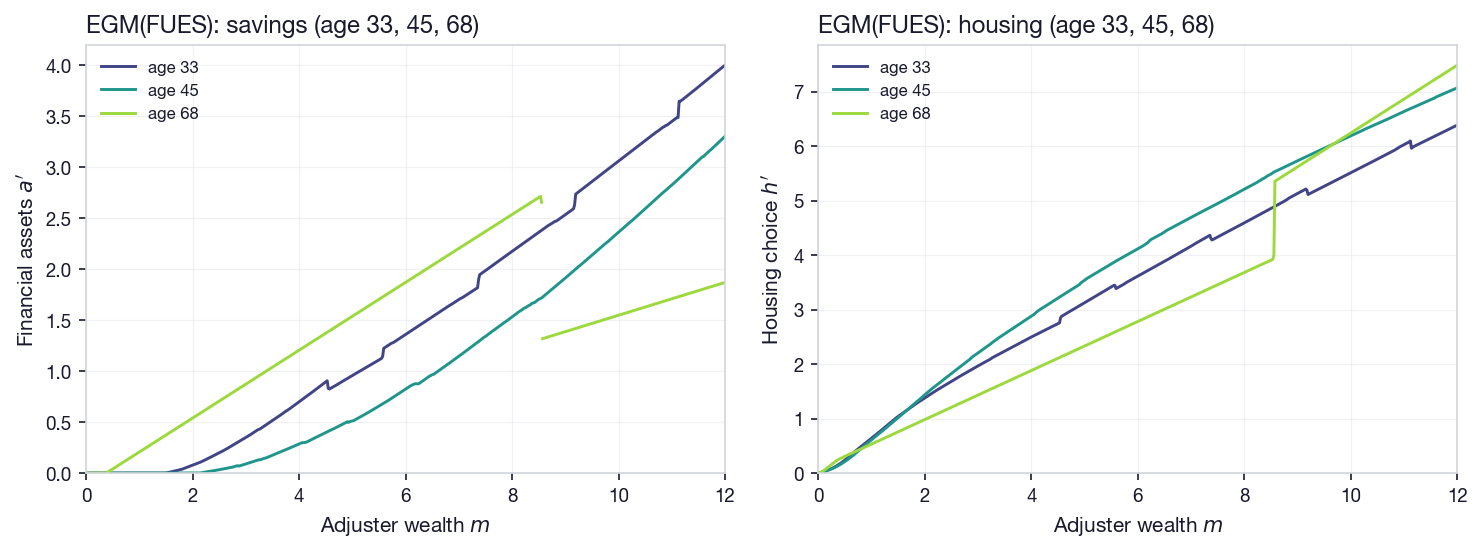

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[33, 45, 68], methods_filter=['FUES'], xlim =12)

Now we use nested EGM (with FUES for the keeper problem only). Golden-section search replaces the EGM in the adjuster stage.

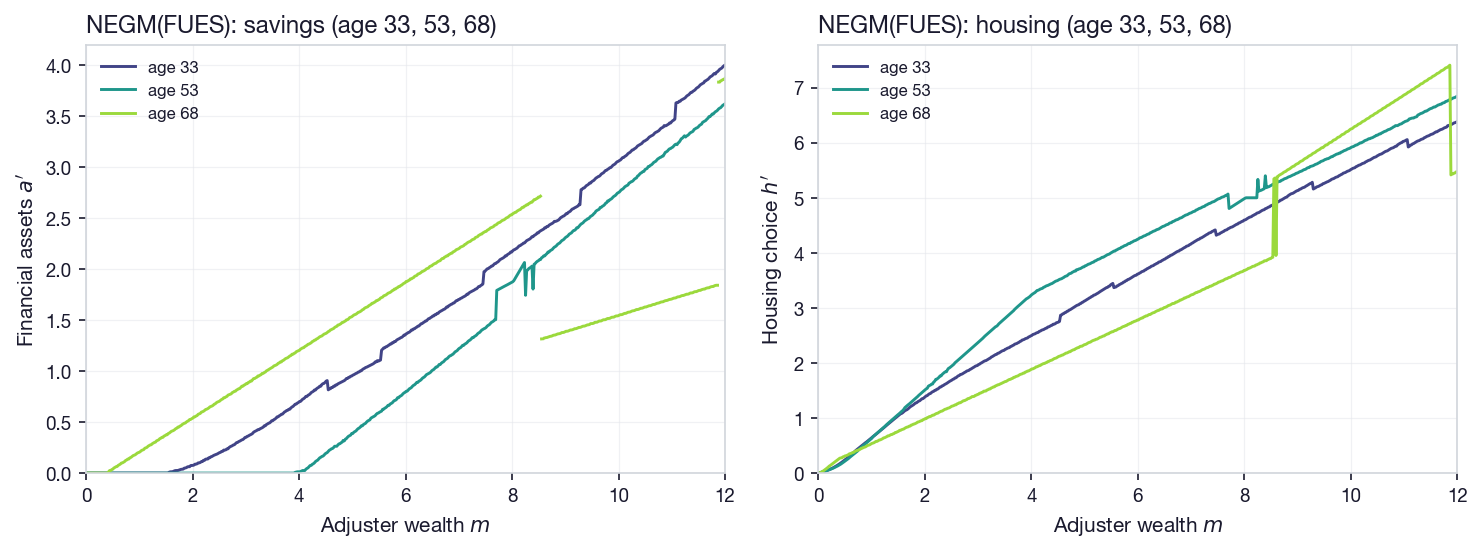

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[33, 53, 68], methods_filter=['NEGM'], xlim =12)

## 4. Adjuster EGM grid

The EGM over the $H_{\succ}$ grid produces an endogenous wealth grid where **multiple housing choices map to the same wealth level**. The left panel shows raw EGM candidates for financial assets $a_{\succ}$; the middle panel shows housing $H_{\succ}$; the right panel shows the value correspondence $\mathrm{v}(\hat{m})$. Each scatter point is one $(H_{\succ}, a_{\succ})$ root of the coupled FOCs. FUES scans this dense cloud to recover the upper envelope in a single pass. MSS and LTM require locally isolated points on the exogenous grid to separate unique segments before interpolating over each of them; because of multiple endogenous grid for each exogenous grid point, neither method can identify these segments.

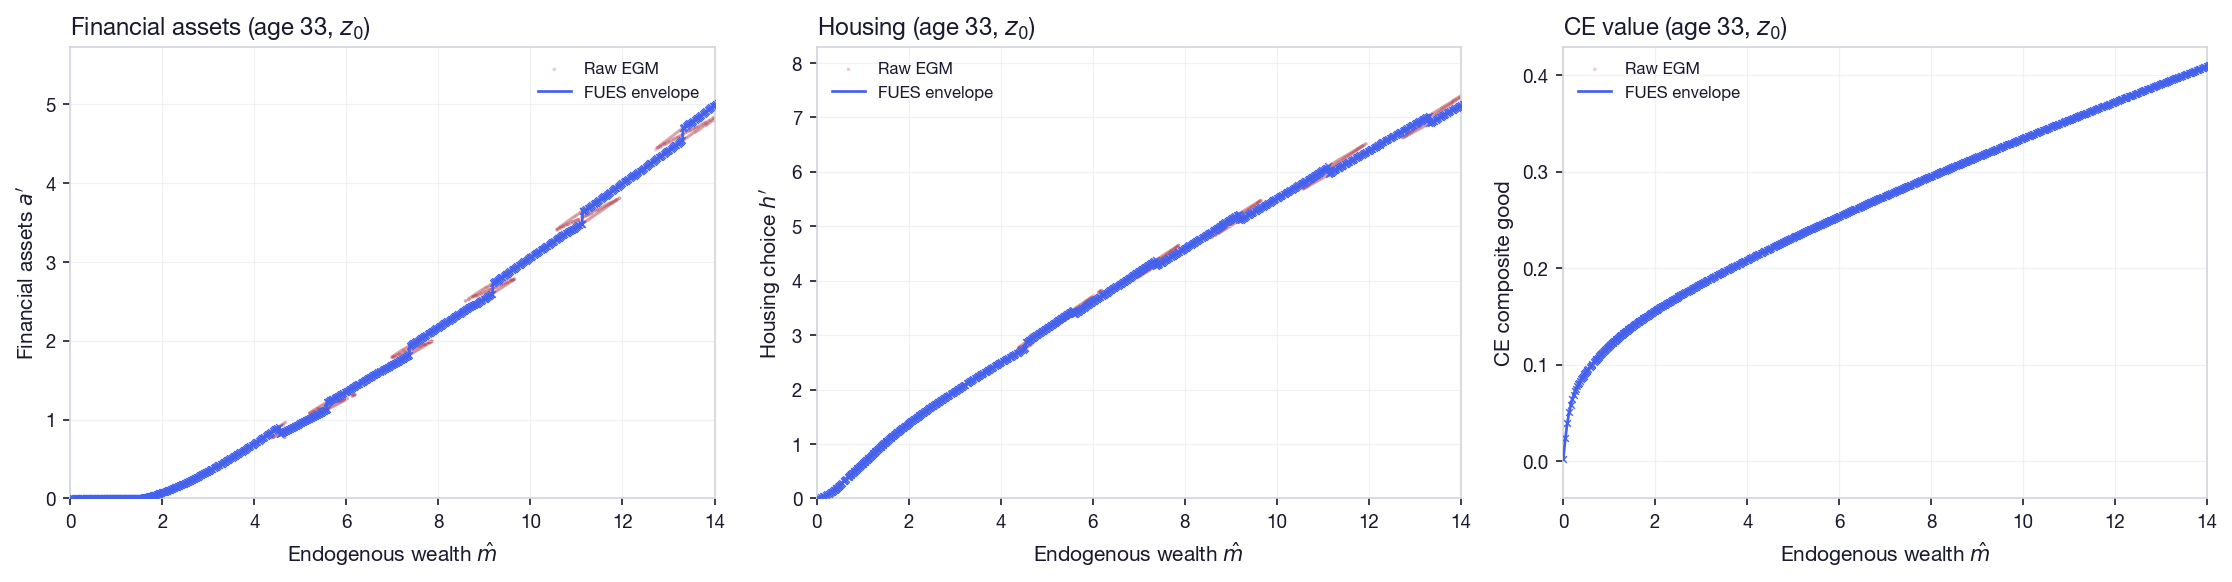

In [ ]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=33, xlim =14)

Interactive versions of the EGM grid (zoom/pan to inspect dense crossing regions). Requires Plotly; skipped gracefully in static environments.

In [ ]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=33)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

Keeper consumption $c$ and savings $a_{\succ}$ as functions of cash-on-hand $w_{\mathrm{kp}}$, for a fixed housing level $H$. The keeper has a single control (consumption); housing passes through unchanged. Both methods use the same 1D EGM + FUES kernel, so policies should be nearly identical. (Recall that for the keeper, MSS *and* LTM can be applied to recover the upper envelope since each exogenous grid point maps to a unique endogenous grid point *and* the continuation-state policy only jumps  upwards)

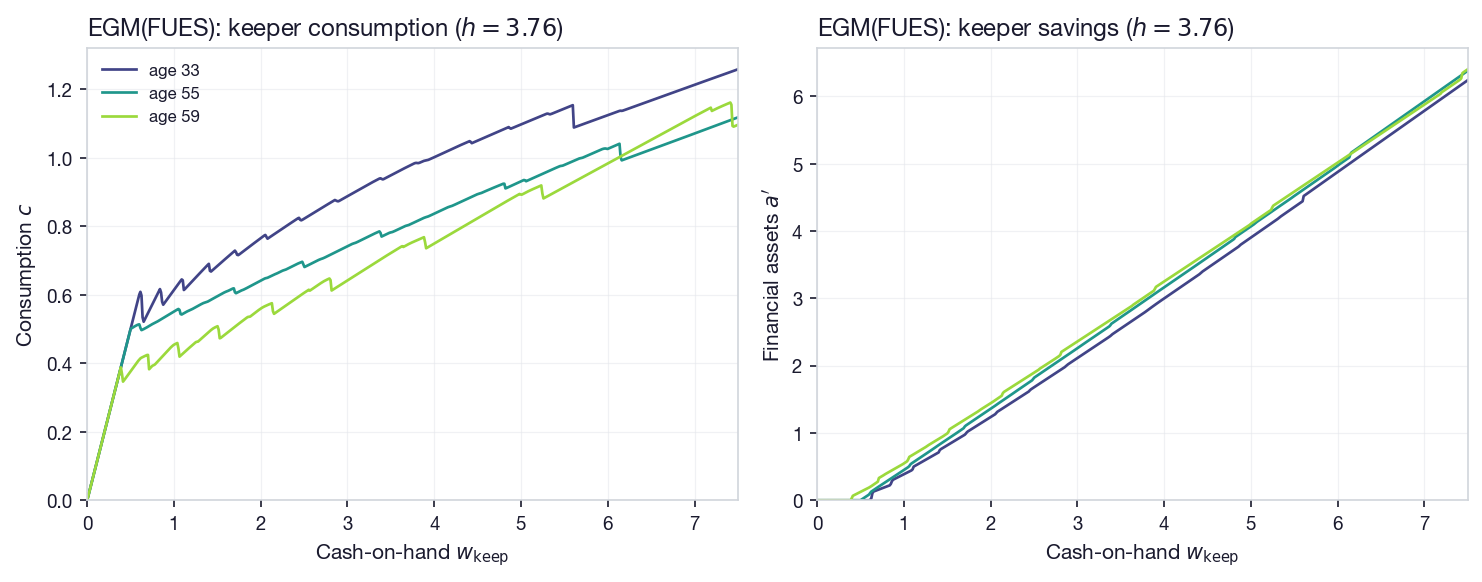

In [ ]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[33, 55, 59], methods_filter=['FUES'])

NEGM(FUES) keeper — same 1D EGM + FUES kernel, so policies should be nearly identical to EGM(FUES).

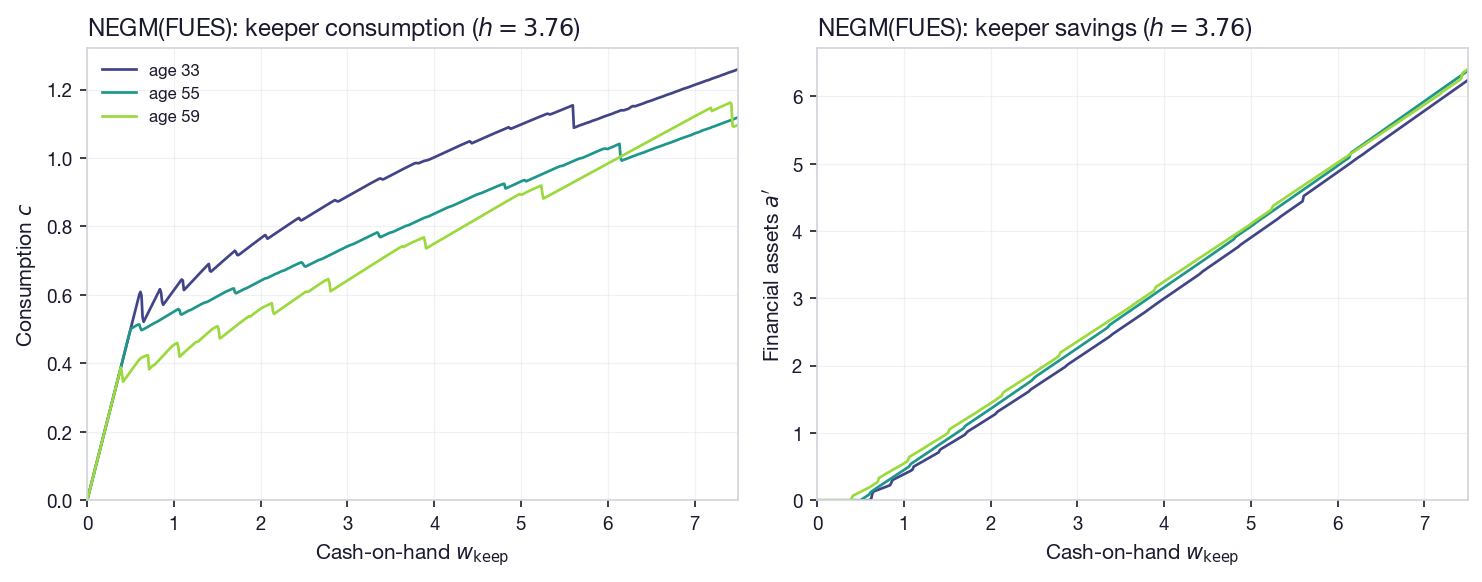

In [ ]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[33, 55, 59], methods_filter=['NEGM'])

### Keeper EGM grid

Raw EGM candidates for one $(z, H)$ slice.

In [ ]:
for method in ['FUES', 'NEGM']:
    labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
    print(f'{labels[method]}')
    fig = nb_plot_keeper_egm(
        results[method]['nest'],
        results[method]['grids'], plot_t=33)
    if fig is not None:
        fig.show()

EGM(FUES)
No keeper cntn data — run with store_cntn=True and generic EGM path
NEGM(FUES)
No keeper cntn data — run with store_cntn=True and generic EGM path


### Value functions (certainty-equivalent)

Raw CRRA values are hugely negative near the borrowing constraint; instead we plot the **certainty-equivalent composite good**: $C_\mathrm{eq} = \bigl((1{-}\rho)\,V\bigr)^{1/(1-\rho)}$, which is positive and in consumption-equivalent units. Keeper (left, for a fixed $H$ slice) and adjuster (right), both methods overlaid.

## 6. Euler equation errors

We forward-simulate 10,000 agents and evaluate two Euler residuals one for the liquid asset Euler equation and one for the housing Euler equation, measured as $\log_{10}$ relative error ($-4$ = four digits of accuracy).

**Consumption FOC** (all agents): $\partial_c\,\mathrm{u}(c, H_{\succ}) = \partial_a\,\mathrm{v}_{\succ}(a_{\succ}, H_{\succ})$, where $\mathrm{v}_{\succ}$ is the continuation value at the start of the next period. Since the keeper stage is identical under both methods, keeper errors are similar.

**Housing FOC** (adjusters only): $(1{+}\tau)\,\partial_c\,\mathrm{u}(c, H_{\succ}) = \partial_H\,\mathrm{v}_{\succ}(a_{\succ}, H_{\succ})$. The factor $(1+\tau)$ is the adjustment cost wedge — an adjuster pays a proportional transaction cost $\tau$ on the new housing stock. This is where the methods diverge: EGM(FUES) inverts this FOC via root-finding; NEGM(FUES) solves it by golden-section search, introducing numerical truncation.

In [ ]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=41)
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


Left: keeper consumption FOC (methods nearly identical). Right: adjuster housing FOC, where EGM(FUES) gains roughly between one and two orders of magnitude in accuracy over NEGM(FUES).

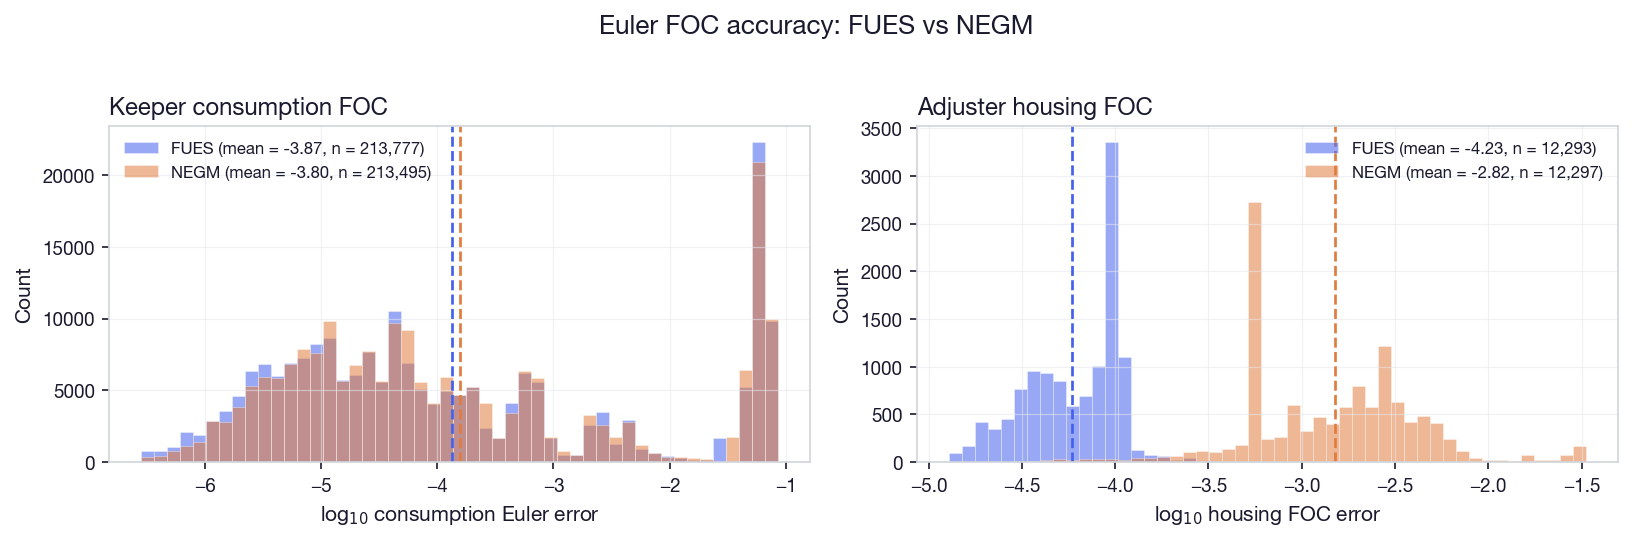

In [ ]:
fig = plot_euler_histogram(euler_results)

## 7. Comparison of aggregates

The advantage of EGM FUES in the adjuster problem here is one to two orders of magnitude in accuracy over NEGM(FUES). Because FUES is already used for the keeper problem, the overall improvement in speed is modest (and will depend on the choice of numerical optimization used in the adjuster stage).

In [ ]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 509 | 350 |
| Adjuster (ms/period) | 94 | 109 |
| Total (ms/period) | 1442 | 1293 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -3.87 | -3.80 |
| Consumption: adjuster | -4.30 | -4.36 |
| Consumption: all | -3.90 | -3.83 |
| Housing: adjuster | -4.23 | -2.82 |
| **Simulation** |  |  |
| CE utility | 56,004.74 | 56,080.01 |
| Mean consumption ($) | 61,963 | 61,965 |
| Mean fin. assets ($) | 36,475 | 36,574 |
| Mean housing ($) | 191,280 | 191,102 |
| Adjustment rate (%) | 12.5 | 12.4 |

## 8. Lifecycle profiles

Mean consumption, financial assets, and housing over the lifecycle. Both methods produce nearly identical aggregate profiles, confirming that the policy differences are localised to the adjuster's housing FOC.

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


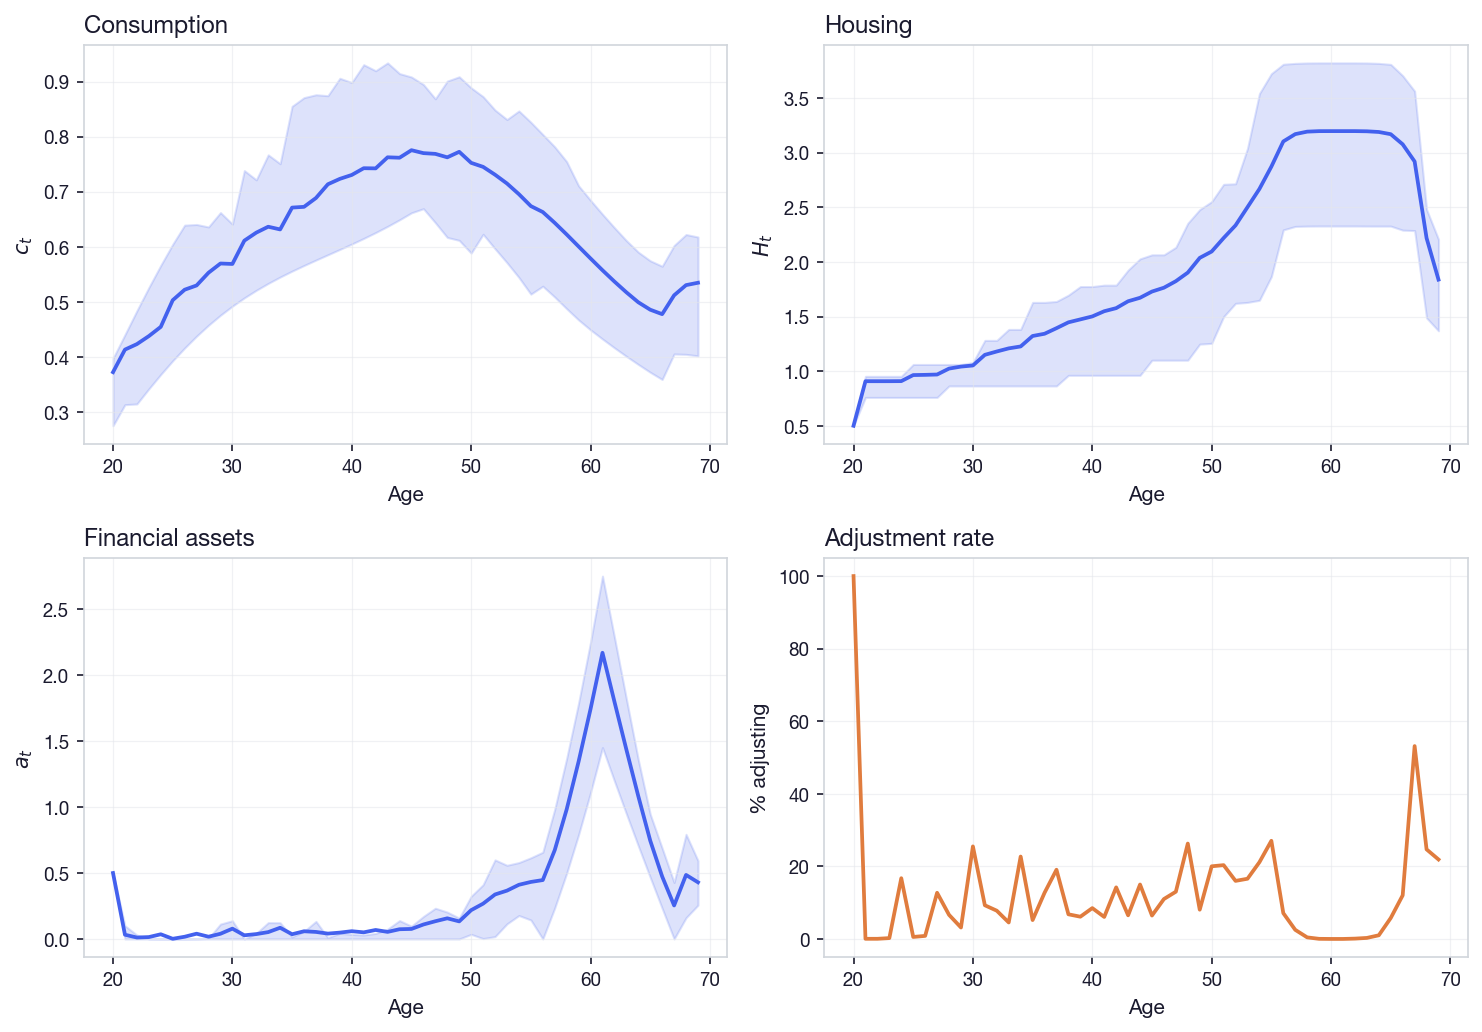

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


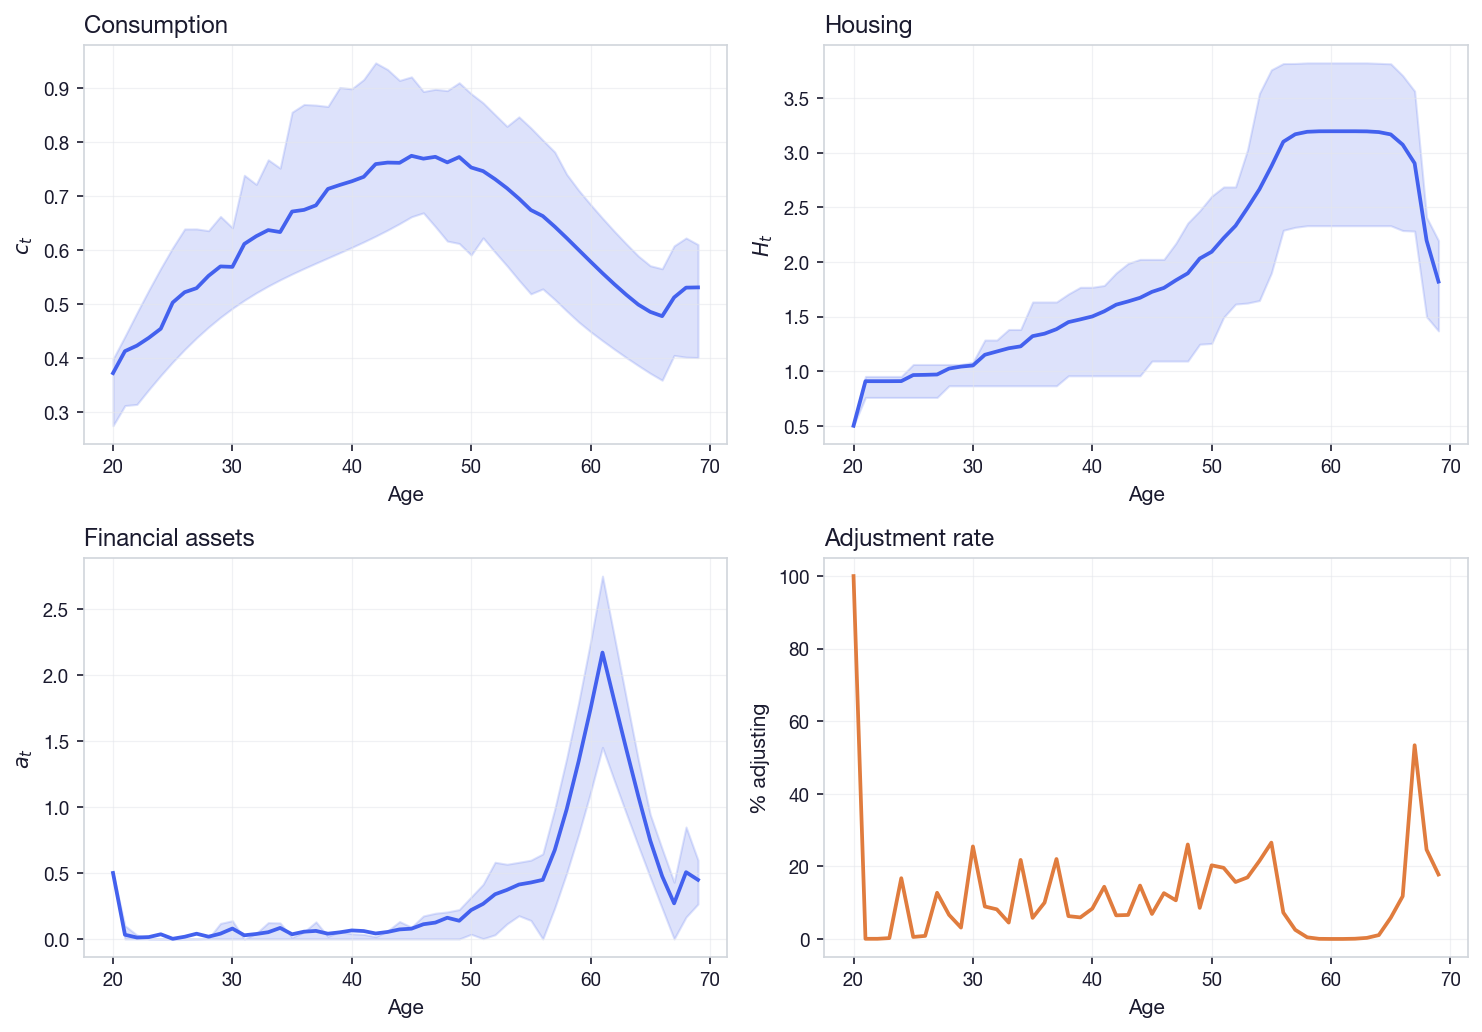

In [ ]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

Simulation moments by 5-year age cohort. Mean and standard deviation of consumption, financial assets, and housing across 10,000 agents.

In [ ]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 42,004.84 | 14,198.29 | 11,844.05 | 19,556.09 | 82,644.24 | 19,119.41 |
| 25–29 | 53,537.02 | 16,233.39 | 2,276.59 | 6,005.37 | 99,283.05 | 27,064.63 |
| 30–34 | 61,468.78 | 16,268.52 | 5,585.49 | 10,736.30 | 116,315.21 | 44,458.07 |
| 35–39 | 69,388.42 | 19,129.69 | 4,712.26 | 10,117.59 | 139,562.90 | 59,939.67 |
| 40–44 | 74,803.63 | 18,951.95 | 6,078.41 | 12,617.95 | 158,759.76 | 69,469.97 |
| 45–49 | 76,993.98 | 17,670.50 | 12,187.54 | 19,107.24 | 185,115.66 | 79,392.57 |
| 50–54 | 72,785.39 | 17,397.96 | 32,009.62 | 31,613.65 | 236,373.18 | 97,769.90 |
| 55–59 | 64,066.70 | 16,889.80 | 77,615.27 | 61,608.36 | 310,722.73 | 100,146.24 |
| 60–64 | 53,784.05 | 14,533.30 | 164,673.18 | 77,827.14 | 319,578.10 | 94,314.00 |
| 65–69 | 50,794.93 | 13,700.04 | 47,763.96 | 39,968.42 | 264,448.08 | 98,734.57 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 42,003.40 | 14,202.25 | 11,840.93 | 19,557.87 | 82,647.38 | 19,107.23 |
| 25–29 | 53,529.34 | 16,228.53 | 2,291.77 | 6,018.53 | 99,284.45 | 27,037.37 |
| 30–34 | 61,529.65 | 16,299.49 | 5,568.88 | 10,761.26 | 116,341.67 | 44,448.84 |
| 35–39 | 69,250.37 | 19,010.20 | 4,827.17 | 10,177.37 | 139,398.14 | 59,923.04 |
| 40–44 | 74,917.38 | 19,051.54 | 5,820.27 | 12,474.12 | 159,310.31 | 69,722.49 |
| 45–49 | 77,022.64 | 17,681.25 | 12,232.90 | 19,164.11 | 184,908.53 | 79,441.87 |
| 50–54 | 72,807.63 | 17,396.06 | 32,141.44 | 31,804.03 | 235,991.03 | 97,752.90 |
| 55–59 | 64,068.50 | 16,895.05 | 77,517.05 | 61,658.17 | 310,565.03 | 100,239.06 |
| 60–64 | 53,777.50 | 14,546.49 | 164,610.91 | 77,881.10 | 319,401.43 | 94,365.95 |
| 65–69 | 50,741.57 | 13,703.02 | 48,890.02 | 40,645.78 | 263,173.05 | 98,722.18 |

---

*Source: `examples/durables/` — Dobrescu and Shanker (2026), Application 2*